# Fleet-level time-explicit LCA of electric vehicles


This notebook extends the [standalone EV example](./example_electric_vehicle_standalone.ipynb) from a single vehicle to a *fleet* of vehicles entering and leaving the stock over time.

Instead of assigning a single, fixed lifetime to one car, we model the fleet with a simple **dynamic Material Flow Analysis (dMFA)** using the [flodym](https://github.com/pik-piam/flodym) library. flodym gives us, from an exogenous stock trajectory and a Weibull lifetime distribution,

- the **annual inflow** of new vehicles (when production happens),
- the **stock** of vehicles in use (when driving happens),
- the **annual outflow** of retired vehicles (when end-of-life happens).

We then plug these three time series into `bw_timex` as `TemporalDistribution`s on the production, use-phase and end-of-life exchanges. The functional unit becomes the entire fleet service over the analysis horizon, and `TimexLCA` returns a time-explicit inventory and dynamic LCIA score for the whole fleet.

> **Note:** This notebook does *not* depend on ecoinvent or premise. As in the standalone example, we make up tiny background databases for 2020, 2030 and 2040 so the notebook is fully reproducible. To run it you only need `bw_timex`, `flodym`, `numpy`, `pandas`, `matplotlib`.

## Background databases


We first set up a fresh brightway project and create the same toy biosphere and three time-stamped background databases (2020, 2030, 2040) as in the standalone example.

In [1]:
import bw2data as bd

bd.projects.set_current("electric_vehicle_fleet")

/usr/local/lib/python3.11/dist-packages/bw2calc/__init__.py:56: UserWarning: 
It seems like you have an AMD/INTEL x64 architecture, but haven't installed pypardiso:

    https://pypi.org/project/pypardiso/

Installing it could give you much faster calculations.

  warnings.warn(PYPARDISO_WARNING)


In [2]:
for db in list(bd.databases):
    del bd.databases[db]

In [3]:
biosphere = bd.Database("biosphere")
biosphere.register()
biosphere.write(
    {
        ("biosphere", "CO2"): {
            "type": "emission",
            "name": "carbon dioxide",
        },
    }
)

background_2020 = bd.Database("background_2020")
background_2020.register()

background_2030 = bd.Database("background_2030")
background_2030.register()

background_2040 = bd.Database("background_2040")
background_2040.register()

background_2020.write({})
background_2030.write({})
background_2040.write({})

background_databases = [background_2020, background_2030, background_2040]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 4559.03it/s]

09:31:14+0000 [info     ] Vacuuming database            


Each background database contains a handful of aggregated processes whose only emission is CO2. The amounts decrease over time, representing a decarbonising background system.

In [4]:
process_co2_emissions = {
    "glider":         (10,   5,    2.5),    # kg CO2 / kg in 2020, 2030, 2040
    "powertrain":     (20,   10,   7.5),
    "battery":        (10,   5,    4),
    "electricity":    (0.5,  0.25, 0.075),  # kg CO2 / kWh
    "glider_eol":     (0.01, 0.0075, 0.005),
    "powertrain_eol": (0.01, 0.0075, 0.005),
    "battery_eol":    (1,    0.5,  0.25),
}

node_co2 = biosphere.get("CO2")

for component_name, gwis in process_co2_emissions.items():
    for database, gwi in zip(background_databases, gwis):
        database.new_node(component_name, name=component_name, location="somewhere").save()
        component = database.get(component_name)
        component["reference product"] = component_name
        component.save()
        production_amount = -1 if "eol" in component_name else 1
        component.new_edge(input=component, amount=production_amount, type="production").save()
        component.new_edge(input=node_co2, amount=gwi, type="biosphere").save()

## Per-vehicle assumptions


We keep the same simple bill-of-materials and use-phase parameters as in the standalone notebook. They will be applied *per vehicle*, and then scaled up to the fleet via the flodym time series.

In [5]:
ELECTRICITY_CONSUMPTION = 0.2      # kWh/km
MILEAGE = 150_000                  # km, lifetime mileage of a single vehicle

# Curb mass split (kg)
MASS_GLIDER = 840
MASS_POWERTRAIN = 80
MASS_BATTERY = 280

## Dynamic MFA of the EV fleet with flodym


We build a minimal **stock-driven** dynamic stock model:

- **Time:** annual resolution from 2015 to 2055.
- **Stock trajectory:** an exogenously prescribed S-curve growing from 0 to a saturation level, mimicking a national EV fleet rolling out over a few decades.
- **Lifetime:** Weibull-distributed, with shape `k = 5` and scale `λ = 14` (years), giving a mean lifetime of around 13 years.

Given stock(t) and the lifetime distribution, flodym's `StockDrivenDSM` solves the (triangular) cohort balance equations and returns annual inflow and outflow.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from flodym import (
    Dimension,
    DimensionSet,
    StockArray,
    StockDrivenDSM,
    WeibullLifetime,
)

### Time and stock


In [7]:
YEAR_START = 2015
YEAR_END   = 2055

years = np.arange(YEAR_START, YEAR_END + 1)

time_dim = Dimension(name="Time", letter="t", items=years.tolist(), dtype=int)
dims = DimensionSet(dim_list=[time_dim])

We prescribe a logistic stock trajectory: the fleet grows from a few thousand vehicles in the late 2010s, ramps up steeply through the 2020s and saturates around 2 million vehicles.

In [8]:
STOCK_SATURATION = 2_000_000   # vehicles
STOCK_MIDPOINT   = 2030        # year of inflection
STOCK_STEEPNESS  = 0.35        # 1/year

stock_values = STOCK_SATURATION / (
    1 + np.exp(-STOCK_STEEPNESS * (years - STOCK_MIDPOINT))
)

stock = StockArray(dims=dims, name="ev_fleet", values=stock_values)

### Lifetime distribution


In [9]:
WEIBULL_SHAPE = 5.0
WEIBULL_SCALE = 14.0   # years

lifetime_model = WeibullLifetime(dims=dims)
lifetime_model.set_prms(
    weibull_shape=np.full(dims.shape, WEIBULL_SHAPE),
    weibull_scale=np.full(dims.shape, WEIBULL_SCALE),
)

The lifetime PDF gives the probability that a vehicle produced in year *c* retires in year *m* (only the upper-triangular part is non-zero, since retirement cannot precede production). For a single cohort, this is just the discretised Weibull PDF as a function of vehicle age.

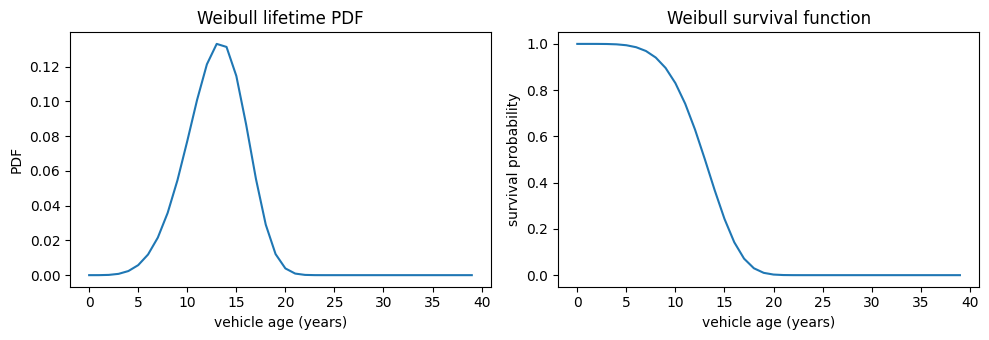

In [10]:
from scipy.stats import weibull_min

ages = np.arange(0, 40)
weibull_pdf_age = weibull_min.pdf(ages, c=WEIBULL_SHAPE, scale=WEIBULL_SCALE)
weibull_sf_age  = weibull_min.sf(ages, c=WEIBULL_SHAPE, scale=WEIBULL_SCALE)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(ages, weibull_pdf_age)
ax[0].set(xlabel="vehicle age (years)", ylabel="PDF", title="Weibull lifetime PDF")
ax[1].plot(ages, weibull_sf_age)
ax[1].set(xlabel="vehicle age (years)", ylabel="survival probability",
         title="Weibull survival function")
fig.tight_layout()

### Solve the dynamic stock model


In [11]:
dsm = StockDrivenDSM(dims=dims, stock=stock, lifetime_model=lifetime_model)
dsm.compute()

`StockDrivenDSM.compute()` populates `dsm.inflow` and `dsm.outflow`. Let's plot the three fleet variables together.

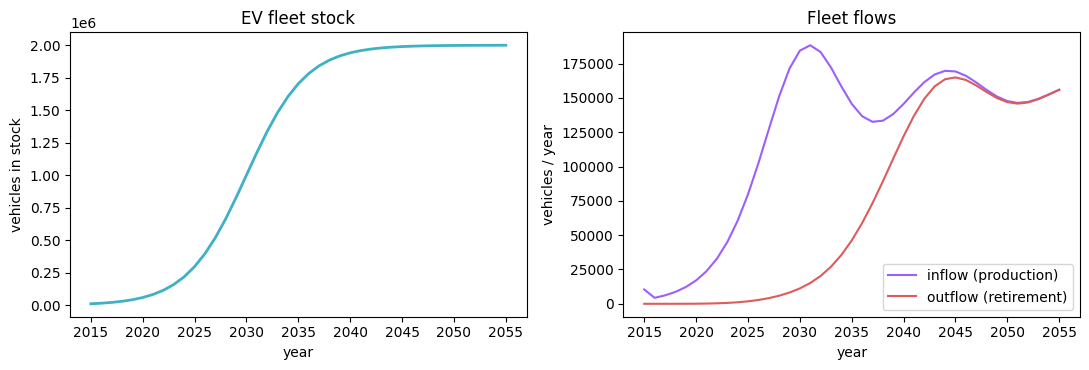

In [12]:
inflow_values  = dsm.inflow.values   # vehicles / year
outflow_values = dsm.outflow.values  # vehicles / year
stock_values_  = dsm.stock.values    # vehicles

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(years, stock_values_, color="#3fb1c5", lw=2)
ax[0].set(xlabel="year", ylabel="vehicles in stock", title="EV fleet stock")
ax[1].plot(years, inflow_values, label="inflow (production)", color="#9c5ffd")
ax[1].plot(years, outflow_values, label="outflow (retirement)", color="#dd5b5b")
ax[1].set(xlabel="year", ylabel="vehicles / year", title="Fleet flows")
ax[1].legend()
fig.tight_layout()

We will scope the LCA to vehicles whose **production** falls in the analysis window `[ANALYSIS_START, ANALYSIS_END]`. This keeps the fleet's life cycle entirely within the horizon of our background databases.

In [13]:
ANALYSIS_START = 2020
ANALYSIS_END   = 2050
FU_YEAR        = 2035   # anchoring year used as the TimexLCA starting datetime

mask = (years >= ANALYSIS_START) & (years <= ANALYSIS_END)

years_window   = years[mask]
inflow_window  = inflow_values[mask]
outflow_window = outflow_values[mask]
stock_window   = stock_values_[mask]

n_total_inflow  = inflow_window.sum()
n_total_outflow = outflow_window.sum()
vehicle_years   = stock_window.sum()  # ≈ fleet × average lifetime in years

print(f"Total vehicles produced  {ANALYSIS_START}-{ANALYSIS_END}: {n_total_inflow:>12,.0f}")
print(f"Total vehicles retired   {ANALYSIS_START}-{ANALYSIS_END}: {n_total_outflow:>12,.0f}")
print(f"Total vehicle-years    in {ANALYSIS_START}-{ANALYSIS_END}: {vehicle_years:>12,.0f}")

Total vehicles produced  2020-2050:    4,132,670
Total vehicles retired   2020-2050:    2,176,165
Total vehicle-years    in 2020-2050:   40,862,003


## From flodym time series to `TemporalDistribution`s


`bw_timex` consumes time-resolved exchanges through the `TemporalDistribution` class from [`bw_temporalis`](https://github.com/brightway-lca/bw_temporalis). Each distribution is a list of `(date, amount)` pairs, where `amount` is the *share* of the exchange that occurs at the given date offset.

We build three fleet-level distributions, all expressed in **years relative to the functional unit's anchoring date `FU_YEAR`**:

- `td_fleet_inflow`  → weights = `inflow(t) / total_inflow`,
- `td_fleet_driving` → weights = `stock(t)  / total_vehicle_years`,
- `td_fleet_outflow` → weights = `outflow(t) / total_outflow`.

Each set of weights sums to 1, so the *amount* of the corresponding exchange (e.g. `N_total` vehicles produced) is preserved and only redistributed in time.

In [14]:
from bw_temporalis import TemporalDistribution

offsets_years = (years_window - FU_YEAR).astype("int64")

td_fleet_inflow = TemporalDistribution(
    date=offsets_years.astype("timedelta64[Y]"),
    amount=inflow_window / inflow_window.sum(),
)

td_fleet_driving = TemporalDistribution(
    date=offsets_years.astype("timedelta64[Y]"),
    amount=stock_window / stock_window.sum(),
)

td_fleet_outflow = TemporalDistribution(
    date=offsets_years.astype("timedelta64[Y]"),
    amount=outflow_window / outflow_window.sum(),
)

Plotting the three distributions side by side gives a quick sanity check: production weight is concentrated in the early years (when the fleet is growing), the stock is centred on the saturation period, and retirements are pushed to the end of the horizon by the long Weibull tail.

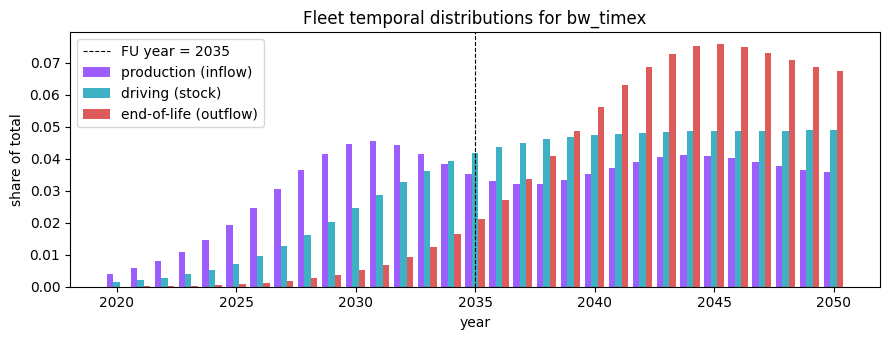

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(years_window - 0.27, td_fleet_inflow.amount,  width=0.27,
       label="production (inflow)",  color="#9c5ffd")
ax.bar(years_window,        td_fleet_driving.amount, width=0.27,
       label="driving (stock)",      color="#3fb1c5")
ax.bar(years_window + 0.27, td_fleet_outflow.amount, width=0.27,
       label="end-of-life (outflow)", color="#dd5b5b")
ax.axvline(FU_YEAR, color="k", ls="--", lw=0.8, label=f"FU year = {FU_YEAR}")
ax.set(xlabel="year", ylabel="share of total",
       title="Fleet temporal distributions for bw_timex")
ax.legend()
fig.tight_layout()

## Building the fleet LCA model


The product system is the same as in the standalone example, but we now interpret it at the *fleet* scale: the functional unit `fleet_driving` represents the entire transport service delivered by the fleet over the analysis horizon.

```{mermaid}
flowchart LR
    glider_production(glider production):::ei-->ev_production
    powertrain_production(powertrain production):::ei-->ev_production
    battery_production(battery production):::ei-->ev_production
    ev_production(ev production):::fg-->|inflow timing|fleet_driving
    electricity_generation(electricity generation):::ei-->|stock timing|fleet_driving
    fleet_driving(fleet driving):::fg-->|outflow timing|used_ev
    used_ev(used ev):::fg-->glider_eol(glider eol):::ei
    used_ev-->powertrain_eol(powertrain eol):::ei
    used_ev-->battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```


In [16]:
if "foreground" in bd.databases:
    del bd.databases["foreground"]
foreground = bd.Database("foreground")
foreground.register()

### Foreground activities


In [17]:
ev_production = foreground.new_node(
    "ev_production", name="production of an electric vehicle", unit="unit",
)
ev_production["reference product"] = "electric vehicle"
ev_production.save()

fleet_driving = foreground.new_node(
    "fleet_driving",
    name="driving an EV fleet over the analysis horizon",
    unit="transport service of the fleet",
)
fleet_driving["reference product"] = "fleet transport"
fleet_driving.save()

used_ev = foreground.new_node(
    "used_ev", name="used electric vehicle", unit="unit",
)
used_ev["reference product"] = "used electric vehicle"
used_ev.save()

### EV production exchanges (per vehicle)


In [18]:
glider_production    = background_2020.get(code="glider")
powertrain_production = background_2020.get(code="powertrain")
battery_production   = background_2020.get(code="battery")

ev_production.new_edge(input=ev_production, amount=1, type="production").save()

glider_to_ev = ev_production.new_edge(
    input=glider_production, amount=MASS_GLIDER, type="technosphere"
)
powertrain_to_ev = ev_production.new_edge(
    input=powertrain_production, amount=MASS_POWERTRAIN, type="technosphere"
)
battery_to_ev = ev_production.new_edge(
    input=battery_production, amount=MASS_BATTERY, type="technosphere"
)

### End-of-life exchanges (per used vehicle)


In [19]:
glider_eol     = background_2020.get(name="glider_eol")
powertrain_eol = background_2020.get(name="powertrain_eol")
battery_eol    = background_2020.get(name="battery_eol")

used_ev.new_edge(input=used_ev, amount=-1, type="production").save()

used_ev_to_glider_eol = used_ev.new_edge(
    input=glider_eol, amount=-MASS_GLIDER, type="technosphere",
)
used_ev_to_powertrain_eol = used_ev.new_edge(
    input=powertrain_eol, amount=-MASS_POWERTRAIN, type="technosphere",
)
used_ev_to_battery_eol = used_ev.new_edge(
    input=battery_eol, amount=-MASS_BATTERY, type="technosphere",
)

### Fleet driving exchanges


We scale the per-vehicle amounts to fleet level using the totals derived from flodym:

- `ev_production` enters with amount `n_total_inflow`,
- electricity is consumed for `n_total_inflow * MILEAGE` km of total fleet travel,
- `used_ev` is produced with amount `-n_total_outflow` (by convention, the used-vehicle process has a production amount of `-1`).

These amounts will be redistributed in time by `TemporalDistribution`s in the next step.

In [20]:
electricity_production = background_2020.get(name="electricity")

fleet_driving.new_edge(input=fleet_driving, amount=1, type="production").save()

ev_to_fleet_driving = fleet_driving.new_edge(
    input=ev_production,
    amount=n_total_inflow,
    type="technosphere",
)

electricity_to_fleet_driving = fleet_driving.new_edge(
    input=electricity_production,
    amount=n_total_inflow * MILEAGE * ELECTRICITY_CONSUMPTION,
    type="technosphere",
)

fleet_driving_to_used_ev = fleet_driving.new_edge(
    input=used_ev,
    amount=-n_total_outflow,
    type="technosphere",
)

### Adding temporal information


Two kinds of `TemporalDistribution`s are at play:

1. **Fleet-level distributions** derived from the flodym MFA, attached to the three `fleet_driving` exchanges. They tell `bw_timex` *when* in time those aggregate flows occur.
2. **Process-level distributions** inside the foreground activities (`ev_production`, `used_ev`) that were already present in the standalone example.

In addition, we can optionally add **temporal evolution** to foreground exchanges to represent technology learning. Here we let electricity demand per vehicle-km improve over build years via `temporal_evolution_factors` on the electricity exchange.


In [21]:
td_glider_production = TemporalDistribution(
    date=np.array([-2, -1, 0], dtype="timedelta64[Y]"),
    amount=np.array([0.7, 0.1, 0.2]),
)

td_produce_powertrain_and_battery = TemporalDistribution(
    date=np.array([-1], dtype="timedelta64[Y]"),
    amount=np.array([1.0]),
)

td_treating_waste = TemporalDistribution(
    date=np.array([3], dtype="timedelta64[M]"),
    amount=np.array([1.0]),
)

In [22]:
# fleet-level timing from flodym
ev_to_fleet_driving["temporal_distribution"]          = td_fleet_inflow
ev_to_fleet_driving.save()

electricity_to_fleet_driving["temporal_distribution"] = td_fleet_driving
electricity_to_fleet_driving.save()

fleet_driving_to_used_ev["temporal_distribution"]     = td_fleet_outflow
fleet_driving_to_used_ev.save()

# per-vehicle timing inside ev_production
glider_to_ev["temporal_distribution"]     = td_glider_production
glider_to_ev.save()
powertrain_to_ev["temporal_distribution"] = td_produce_powertrain_and_battery
powertrain_to_ev.save()
battery_to_ev["temporal_distribution"]    = td_produce_powertrain_and_battery
battery_to_ev.save()

# per-vehicle timing inside used_ev
used_ev_to_glider_eol["temporal_distribution"]     = td_treating_waste
used_ev_to_glider_eol.save()
used_ev_to_powertrain_eol["temporal_distribution"] = td_treating_waste
used_ev_to_powertrain_eol.save()
used_ev_to_battery_eol["temporal_distribution"]    = td_treating_waste
used_ev_to_battery_eol.save()

### Optional: vintage-specific use-phase efficiency

If you want the fleet mix in a given calendar year (e.g. 2040) to keep track of the efficiencies of each vehicle vintage (2025, 2026, ..., 2039), attach `temporal_evolution_factors` and set `temporal_evolution_reference` to `"consumer"` on the fleet electricity exchange.

With `consumer` reference, each use-phase event is scaled using the **consumer/vintage timestamp** instead of the producer timestamp.


In [ ]:
# Example vintage-specific EV efficiency trajectory (relative to a 2025 baseline)
# Adjust values to your own fleet assumptions
vintage_efficiency_factors = {
    np.datetime64(f"{year}-01-01").astype("datetime64[s]").astype(object): 1 + 0.01 * (year - 2025)
    for year in range(2025, 2041)
}

electricity_to_fleet_driving["temporal_evolution_factors"] = vintage_efficiency_factors
electricity_to_fleet_driving["temporal_evolution_reference"] = "consumer"
electricity_to_fleet_driving.save()


In [ ]:
from datetime import datetime

# Optional foreground technology learning: EVs built in later years use less electricity per km
electricity_to_fleet_driving["temporal_evolution_factors"] = {
    datetime(2020, 1, 1): 1.00,
    datetime(2030, 1, 1): 0.88,
    datetime(2040, 1, 1): 0.80,
    datetime(2050, 1, 1): 0.75,
}
electricity_to_fleet_driving.save()


In [23]:
for db in bd.databases:
    bd.Database(db).process()

### Characterization method


In [24]:
bd.Method(("GWP", "example")).write(
    [
        (("biosphere", "CO2"), 1),
    ]
)

## Time-explicit fleet LCA with `TimexLCA`


In [25]:
from datetime import datetime
from bw_timex import TimexLCA

method = ("GWP", "example")

database_dates = {
    "background_2020": datetime.strptime("2020", "%Y"),
    "background_2030": datetime.strptime("2030", "%Y"),
    "background_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic",
}

We anchor the timeline at `FU_YEAR` (i.e. 2035) by passing it as `starting_datetime` to `build_timeline`. All the relative offsets in our `TemporalDistribution`s are interpreted with respect to that anchor.

In [26]:
fleet_driving = bd.get_node(database="foreground", code="fleet_driving")
tlca = TimexLCA({fleet_driving: 1}, method, database_dates)

tlca.build_timeline(
    starting_datetime=datetime(FU_YEAR, 1, 1),
    temporal_grouping="year",
)

2026-05-02 09:31:22.934 | INFO     | bw_timex.timex_lca:__init__:122 - Initializing TimexLCA object...


2026-05-02 09:31:22.935 | INFO     | bw_timex.timex_lca:__init__:139 - Calculating base LCA...


2026-05-02 09:31:22.980 | INFO     | bw_timex.timex_lca:__init__:156 - Collecting node infos...


2026-05-02 09:31:23.000 | INFO     | bw_timex.timex_lca:build_timeline:252 - No edge filter function provided. Skipping all edges in background databases.


2026-05-02 09:31:23.006 | INFO     | bw_timex.timex_lca:build_timeline:268 - Creating activity time mapping...


...

2026-05-02 09:31:23.296 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:560 - Reference date 2050-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-02 09:31:23.297 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:560 - Reference date 2050-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-02 09:31:23.299 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:560 - Reference date 2050-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


2026-05-02 09:31:23.301 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:560 - Reference date 2050-01-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2018-01-01,glider,2020-01-01,production of an electric vehicle,588.0,{'background_2020': 1}
1,2019-01-01,glider,2020-01-01,production of an electric vehicle,84.0,{'background_2020': 1}
2,2019-01-01,powertrain,2020-01-01,production of an electric vehicle,80.0,{'background_2020': 1}
3,2019-01-01,battery,2020-01-01,production of an electric vehicle,280.0,{'background_2020': 1}
4,2019-01-01,glider,2021-01-01,production of an electric vehicle,588.0,{'background_2020': 1}
...,...,...,...,...,...,...
337,2050-01-01,used electric vehicle,2035-01-01,driving an EV fleet over the analysis horizon,-146919.568686,None
338,2050-01-01,glider,2050-01-01,production of an electric vehicle,168.0,{'background_2040': 1}
339,2050-01-01,glider_eol,2050-01-01,used electric vehicle,-840.0,{'background_2040': 1}
340,2050-01-01,powertrain_eol,2050-01-01,used electric vehicle,-80.0,{'background_2040': 1}


### Inventory and static score


In [27]:
tlca.lci()
tlca.static_lcia()
print(f"Time-explicit fleet GWP: {tlca.static_score:,.0f} kg CO2-eq")
print(f"Static (2020 background) fleet GWP: {tlca.base_lca.score:,.0f} kg CO2-eq")

2026-05-02 09:31:23.384 | INFO     | bw_timex.timex_lca:lci:385 - Expanding matrices...


2026-05-02 09:31:24.428 | INFO     | bw_timex.timex_lca:lci:404 - Calculating dynamic inventory...


Time-explicit fleet GWP: 39,863,831,628 kg CO2-eq
Static (2020 background) fleet GWP: 115,517,570,589 kg CO2-eq


On a per-vehicle basis the time-explicit score is much smaller, because most of the fleet is produced and driven in years where the background system has decarbonised compared to 2020.

In [28]:
print(f"Per-vehicle GWP, time-explicit: "
      f"{tlca.static_score / n_total_inflow:,.0f} kg CO2-eq / vehicle")
print(f"Per-vehicle GWP, static (2020):  "
      f"{tlca.base_lca.score / n_total_inflow:,.0f} kg CO2-eq / vehicle")

Per-vehicle GWP, time-explicit: 9,646 kg CO2-eq / vehicle
Per-vehicle GWP, static (2020):  27,952 kg CO2-eq / vehicle


### Dynamic characterization


We characterize the dynamic inventory using the IPCC AR6 CO2 radiative-forcing function (reusing the `dynamic_characterization` package as in the standalone notebook).

In [29]:
from dynamic_characterization.ipcc_ar6.radiative_forcing import characterize_co2

characterization_functions = {
    bd.get_node(code="CO2").id: characterize_co2,
}

tlca.dynamic_lcia(
    metric="radiative_forcing",
    fixed_time_horizon=True,
    characterization_functions=characterization_functions,
)
print(f"Cumulative fleet radiative forcing: {tlca.dynamic_score:.3e} W/m²")

Cumulative fleet radiative forcing: 3.550e-03 W/m²


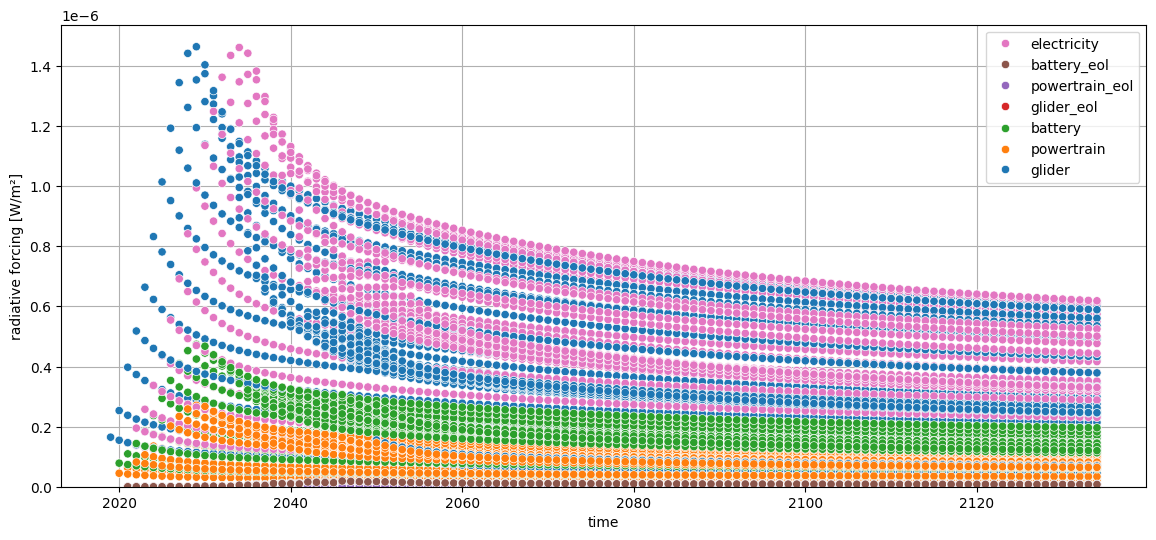

In [30]:
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True)

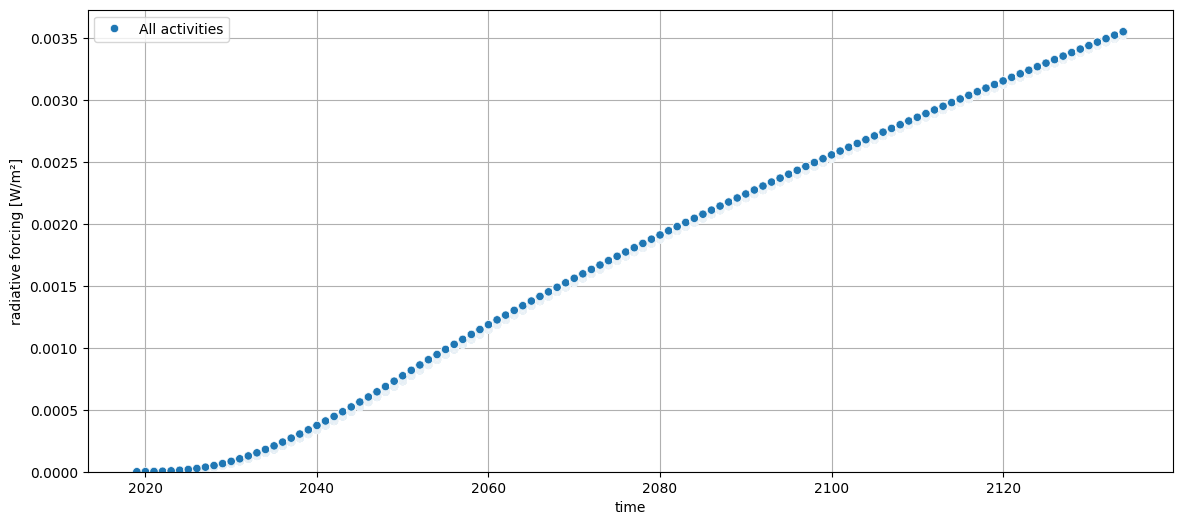

In [31]:
tlca.plot_dynamic_characterized_inventory(sum_activities=True, cumsum=True)

And the same in GWP units, with a 100-year time horizon:

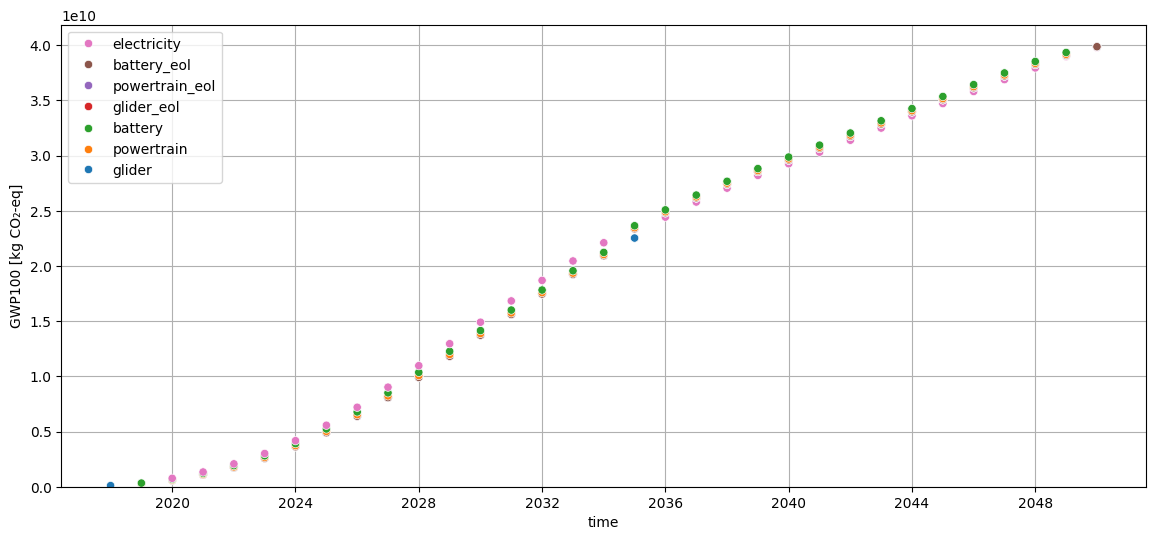

In [32]:
tlca.dynamic_lcia(
    metric="GWP",
    fixed_time_horizon=False,
    time_horizon=100,
    characterization_functions=characterization_functions,
)
tlca.plot_dynamic_characterized_inventory(sum_emissions_within_activity=True, cumsum=True)

## Waterfall comparison: static vs. time-explicit vs. prospective


To put the time-explicit fleet result in context, we compare it to two static bookends:

- a **static (2020) score**: the whole fleet sourced from `background_2020`,
- a **prospective (2040) score**: the whole fleet sourced from `background_2040`.

We re-use `bw_timex.utils.plot_characterized_inventory_as_waterfall`, which expects first-level contribution scores per background activity. To get them, we walk through the fleet's exchanges (and the sub-exchanges of `ev_production` and `used_ev`) and run a static LCIA for each one. The middle stack of the waterfall comes from the GWP100 time-explicit characterized inventory we just computed.

In [33]:
import bw2calc as bc
from bw_timex.utils import plot_characterized_inventory_as_waterfall

static_scores = {}
for exc in fleet_driving.technosphere():
    if exc.input == ev_production:
        for subexc in exc.input.technosphere():
            tlca.base_lca.lcia(demand={subexc.input.id:
                exc.amount * subexc.amount * subexc.input.rp_exchange().amount})
            static_scores[subexc.input["name"]] = tlca.base_lca.score
    elif exc.input == used_ev:
        for subexc in exc.input.technosphere():
            tlca.base_lca.lcia(demand={subexc.input.id:
                exc.amount * subexc.amount * subexc.input.rp_exchange().amount})
            static_scores[subexc.input["name"]] = tlca.base_lca.score
    else:
        tlca.base_lca.lcia(demand={exc.input.id: exc.amount})
        static_scores[exc.input["name"]] = tlca.base_lca.score

For the prospective scores we copy the foreground processes and relink every background input to its 2040 counterpart, then redo the same first-level contribution analysis.

In [34]:
for code in ("prospective_fleet_driving",
             "prospective_ev_production",
             "prospective_used_ev"):
    if ("foreground", code) in bd.Database("foreground"):
        foreground.get(code=code).delete()

prospective_fleet_driving = fleet_driving.copy(
    code="prospective_fleet_driving",
    name="driving an EV fleet (2040 background)",
)

for exc in prospective_fleet_driving.technosphere():
    if exc.input == ev_production:
        prospective_ev_production = ev_production.copy(
            code="prospective_ev_production",
            name="production of an electric vehicle (2040 background)",
        )
        exc.input = prospective_ev_production
        exc.save()
        for subexc in prospective_ev_production.technosphere():
            subexc.input = bd.get_node(
                database=background_2040.name,
                name=subexc.input["name"],
                product=subexc.input["reference product"],
                location=subexc.input["location"],
            )
            subexc.save()
    elif exc.input == used_ev:
        prospective_used_ev = used_ev.copy(
            code="prospective_used_ev",
            name="used electric vehicle (2040 background)",
        )
        exc.input = prospective_used_ev
        exc.save()
        for subexc in prospective_used_ev.technosphere():
            subexc.input = bd.get_node(
                database=background_2040.name,
                name=subexc.input["name"],
                product=subexc.input["reference product"],
                location=subexc.input["location"],
            )
            subexc.save()
    else:
        exc.input = bd.get_node(
            database=background_2040.name,
            name=exc.input["name"],
            product=exc.input["reference product"],
            location=exc.input["location"],
        )
        exc.save()

prospective_scores = {}
lca = bc.LCA({prospective_fleet_driving.key: 1}, method)
lca.lci(factorize=True)
for exc in prospective_fleet_driving.technosphere():
    if exc.input["name"] in (prospective_ev_production["name"],
                            prospective_used_ev["name"]):
        for subexc in exc.input.technosphere():
            lca.lcia(demand={subexc.input.id:
                exc.amount * subexc.amount * subexc.input.rp_exchange().amount})
            prospective_scores[subexc.input["name"]] = lca.score
    else:
        lca.lcia(demand={exc.input.id: exc.amount})
        prospective_scores[exc.input["name"]] = lca.score

print(f"Static (2020)     fleet GWP: {sum(static_scores.values()):,.0f} kg CO2-eq")
print(f"Time-explicit     fleet GWP: {tlca.dynamic_score:,.0f} kg CO2-eq")
print(f"Prospective (2040) fleet GWP: {sum(prospective_scores.values()):,.0f} kg CO2-eq")

Static (2020)     fleet GWP: 115,517,571,161 kg CO2-eq
Time-explicit     fleet GWP: 39,863,831,628 kg CO2-eq
Prospective (2040) fleet GWP: 25,247,648,792 kg CO2-eq


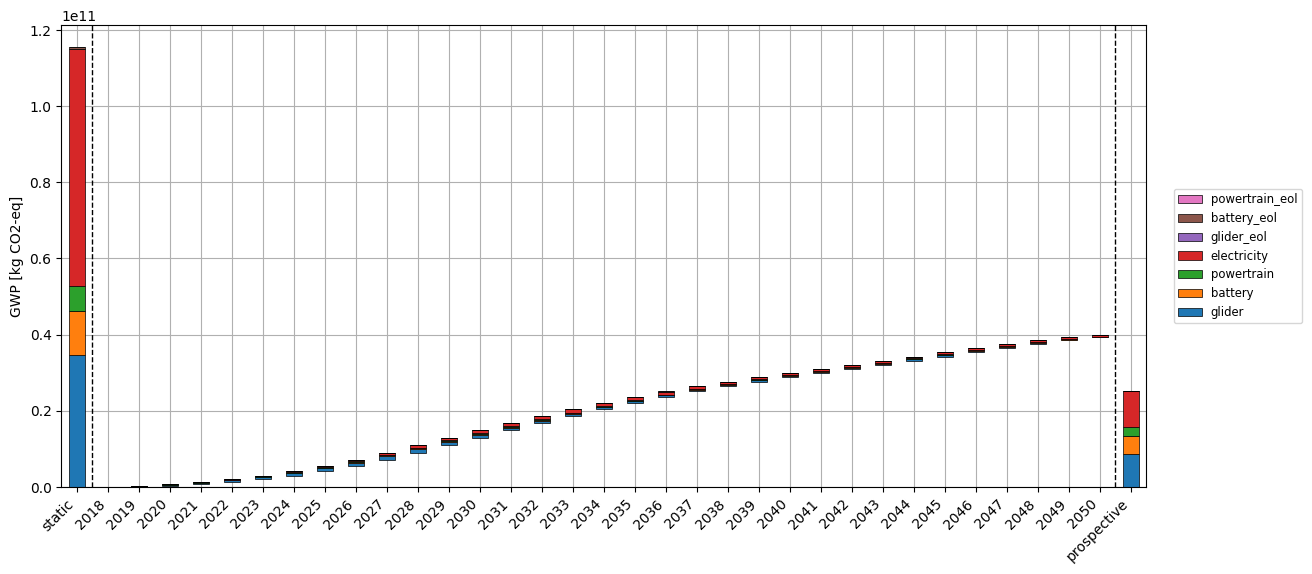

In [35]:
order_stacked_activities = [
    glider_production["name"],
    battery_production["name"],
    powertrain_production["name"],
    electricity_production["name"],
    glider_eol["name"],
    battery_eol["name"],
    powertrain_eol["name"],
]

plot_characterized_inventory_as_waterfall(
    tlca,
    static_scores=static_scores,
    prospective_scores=prospective_scores,
    order_stacked_activities=order_stacked_activities,
)

The leftmost bar represents the fleet's GWP100 if every background process were sourced from `background_2020`, the rightmost bar from `background_2040`. The stacked bars in between are the time-explicit fleet emissions, broken down by year and contributing background activity. Together they show how the fleet's footprint shifts as the underlying electricity and material production decarbonise.

## Wrap-up


### Interpreting vintage improvements

Yes — this setup can represent **vintage-dependent efficiency improvements** in a practical way. The exchange amount is adjusted using the factor at the *time when that exchange occurs*.

- If a vehicle is produced in a later year, its production and use exchanges can automatically pick up later (more efficient) factors.
- Existing vehicles can also keep improving at later times **if** you model this as time-varying use-phase exchanges (as done here with a fleet-level driving exchange).
- If you instead want fixed technical vintages (e.g., a 2025 car keeps its 2025 efficiency forever), represent each cohort with separate activities or separate temporal distributions so each cohort keeps its own use intensity.

So, `temporal_evolution_factors` can capture both a system-wide efficiency trend and (with a cohort-resolved foreground design) strict vintage-locking behavior.


We replaced the single-vehicle, fixed-lifetime assumption from the standalone notebook by a fleet-level model in which the **timing** of production, driving and retirement is derived from a dynamic stock model with a Weibull lifetime, computed with `flodym`. Plugging the resulting time series in as `TemporalDistribution`s on the corresponding fleet-level exchanges is enough for `bw_timex` to produce a time-explicit, dynamic inventory and impact score for the whole fleet.

From here you can experiment with:

- different stock trajectories (e.g. faster ramp-up, smaller saturation),
- different lifetime distributions (`NormalLifetime`, `LogNormalLifetime`, `FoldedNormalLifetime`, `FixedLifetime`) and their parameters,
- richer foreground systems (battery replacement, second-life batteries) by adding more stocks to the flodym model and corresponding exchanges in the brightway model.